
<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# Previsão da Demanda

## Eduardo Pécora, Ph.D.

**Objetivos do módulo:**
- Compreender os componentes de uma série temporal
- Aplicar decomposição clássica e STL
- Interpretar ACF e PACF para identificar periodicidade
- Tratar sazonalidade múltipla e feriados


# Instalação e importações

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Estilo dos gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 1. Geração do dataset simulado

Vamos simular uma série de **demanda mensal de um produto** com:
- Tendência de crescimento suave
- Sazonalidade anual (pico no fim do ano)
- Ruído aleatório
- Alguns eventos pontuais (promoções)

In [158]:
n

72

In [159]:
np.random.seed(42)

# Período: Jan/2018 a Dez/2023 (72 meses)
datas = pd.date_range(start='2018-01-01', end='2023-12-31', freq='MS')
n = len(datas)

# Componentes
tendencia   = np.linspace(800, 1200, n)                        # crescimento linear
sazonalidade = 200 * np.sin(2 * np.pi * np.arange(n) / 12 - np.pi/2)  # período 12 meses
ruido        = np.random.normal(0, 60, n)

# Eventos pontuais (promoções em Jul/2019 e Nov/2021)
eventos = np.zeros(n)
eventos[18] = 350   # Jul/2019
eventos[46] = 280   # Nov/2021

demanda = tendencia + sazonalidade + ruido + eventos

# Outliers
outlier_indices = [15, 37, 58]
demanda[outlier_indices] = demanda[outlier_indices] + [270, -360, 590]

demanda = np.maximum(demanda, 0)   # não pode ser negativa


serie = pd.Series(demanda.round(0), index=datas, name='demanda')

print(f'Série criada: {len(serie)} observações ({serie.index[0].date()} → {serie.index[-1].date()})')
print(f'Demanda média: {serie.mean():.0f} unidades/mês')
print(f'Mín: {serie.min():.0f}  |  Máx: {serie.max():.0f}')

Série criada: 72 observações (2018-01-01 → 2023-12-01)
Demanda média: 1009 unidades/mês
Mín: 358  |  Máx: 1637


# Análise Gráfica

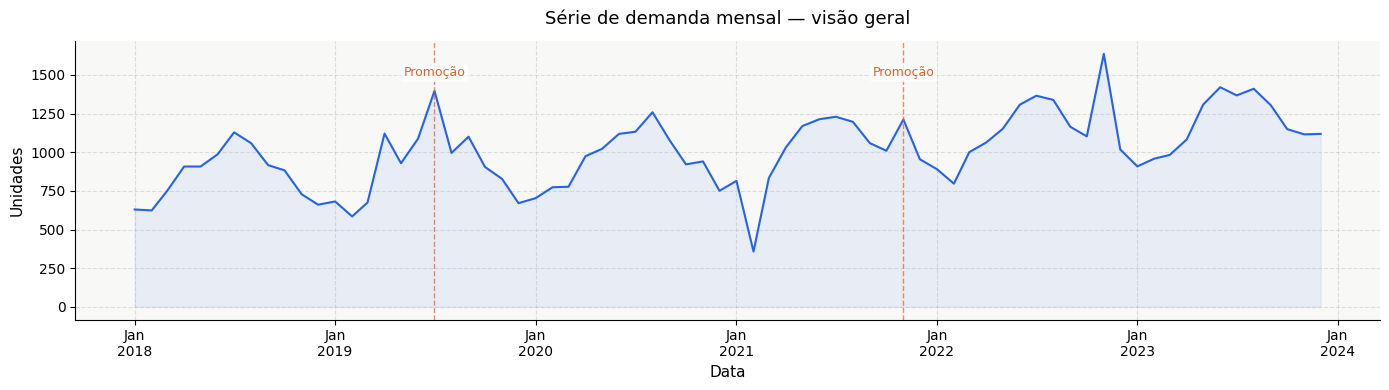

In [160]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(serie.index, serie.values, color='#2563EB', linewidth=1.5, label='Demanda observada')
ax.fill_between(serie.index, serie.values, alpha=0.08, color='#2563EB')

# Marcar eventos
for idx in [18, 46]:
    ax.axvline(datas[idx], color='#E85D24', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(datas[idx], serie.max() * 0.95, 'Promoção',
            fontsize=9, color='#E85D24', ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_title('Série de demanda mensal — visão geral', pad=12)
ax.set_xlabel('Data')
ax.set_ylabel('Unidades')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.tight_layout()
plt.show()

---
## 2. Componentes de uma série temporal

Toda série temporal pode ser decomposta em:

| Componente | O que representa |
|---|---|
| **Tendência** (T) | Direção de longo prazo: crescimento, queda ou estabilidade |
| **Sazonalidade** (S) | Padrão que se repete em intervalos fixos (semana, mês, ano) |
| **Ciclicidade** (C) | Oscilações de longo prazo sem período fixo (ex.: ciclos econômicos) |
| **Ruído** (R) | Variação aleatória, sem padrão explicável |

### Modelos de decomposição

**Aditivo:** `Y = T + S + R`  
→ Use quando a amplitude da sazonalidade é constante ao longo do tempo.

**Multiplicativo:** `Y = T × S × R`  
→ Use quando a amplitude da sazonalidade **cresce proporcional à tendência**.

## Exemplos

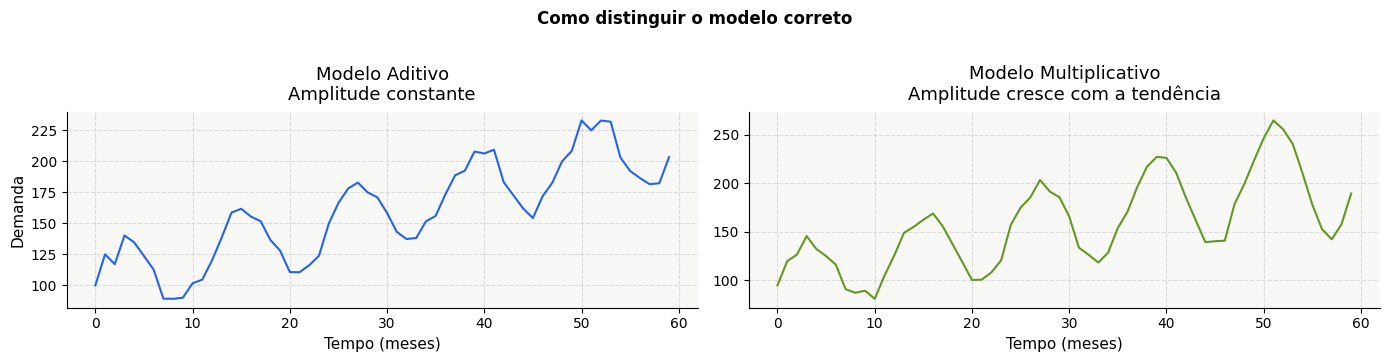

→ Nossa série: amplitude da sazonalidade parece CONSTANTE → modelo aditivo


In [161]:
# ─── Dica visual: como identificar o modelo certo ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

t = np.arange(60)
trend = 100 + 2*t

# Aditivo: amplitude constante
s_add = 30 * np.sin(2*np.pi*t/12)
y_add = trend + s_add + np.random.normal(0, 5, 60)
axes[0].plot(y_add, color='#2563EB', linewidth=1.5)
axes[0].set_title('Modelo Aditivo\nAmplitude constante', pad=8)
axes[0].set_xlabel('Tempo (meses)')
axes[0].set_ylabel('Demanda')

# Multiplicativo: amplitude cresce com tendência
s_mult = 1 + 0.3 * np.sin(2*np.pi*t/12)
y_mult = trend * s_mult + np.random.normal(0, 5, 60)
axes[1].plot(y_mult, color='#639922', linewidth=1.5)
axes[1].set_title('Modelo Multiplicativo\nAmplitude cresce com a tendência', pad=8)
axes[1].set_xlabel('Tempo (meses)')

plt.suptitle('Como distinguir o modelo correto', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('→ Nossa série: amplitude da sazonalidade parece CONSTANTE → modelo aditivo')

## Voltando à Análise

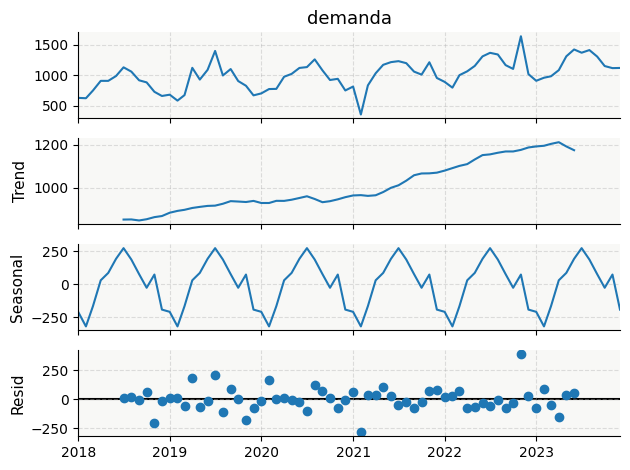

In [162]:
# Para decomposição, vamos usar a data como índice

resultado = seasonal_decompose(serie, model='additive', period=12)
resultado.plot()
plt.show()

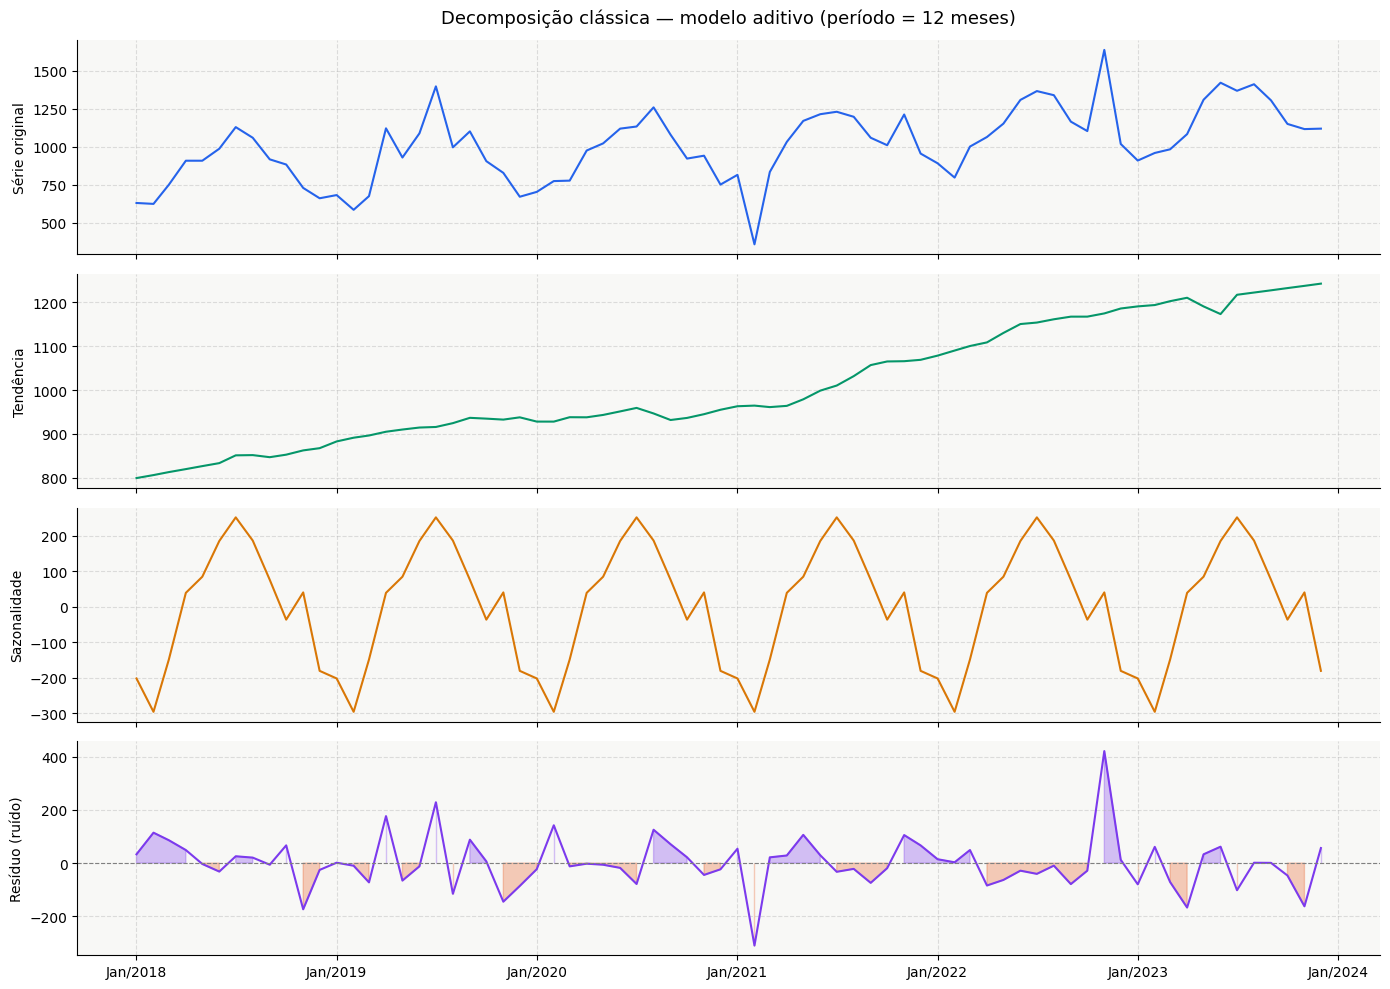

In [163]:
# Decomposição clássica — modelo aditivo, período 12 meses
decomp_classica = seasonal_decompose(
    serie,
    model='additive',
    period=12,
    extrapolate_trend='freq'   # evita NaN nas bordas
)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
cores = ['#2563EB', '#059669', '#D97706', '#7C3AED']
titulos = ['Série original', 'Tendência', 'Sazonalidade', 'Resíduo (ruído)']
componentes = [
    serie,
    decomp_classica.trend,
    decomp_classica.seasonal,
    decomp_classica.resid
]

for ax, comp, cor, titulo in zip(axes, componentes, cores, titulos):
    ax.plot(comp, color=cor, linewidth=1.5)
    ax.set_ylabel(titulo, fontsize=10)
    if titulo == 'Resíduo (ruído)':
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.fill_between(comp.index, comp.values, 0,
                        where=comp.values > 0, alpha=0.3, color=cor)
        ax.fill_between(comp.index, comp.values, 0,
                        where=comp.values < 0, alpha=0.3, color='#E85D24')

axes[0].set_title('Decomposição clássica — modelo aditivo (período = 12 meses)', pad=12)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.tight_layout()
plt.show()

---
## 3. ACF e PACF — Diagnóstico de autocorrelação

**ACF** (Autocorrelation Function): correlação da série com versões defasadas de si mesma.  
**PACF** (Partial ACF): correlação com lag k removendo efeito dos lags intermediários.

### Como ler os gráficos
| Padrão no ACF | Interpretação |
|---|---|
| Pico no lag k | Período sazonal de k unidades de tempo |
| Decaimento lento | Série com tendência (não estacionária) |
| Picos em 12, 24, 36... | Sazonalidade anual em dados mensais |
| Picos em 7, 14, 21... | Sazonalidade semanal em dados diários |

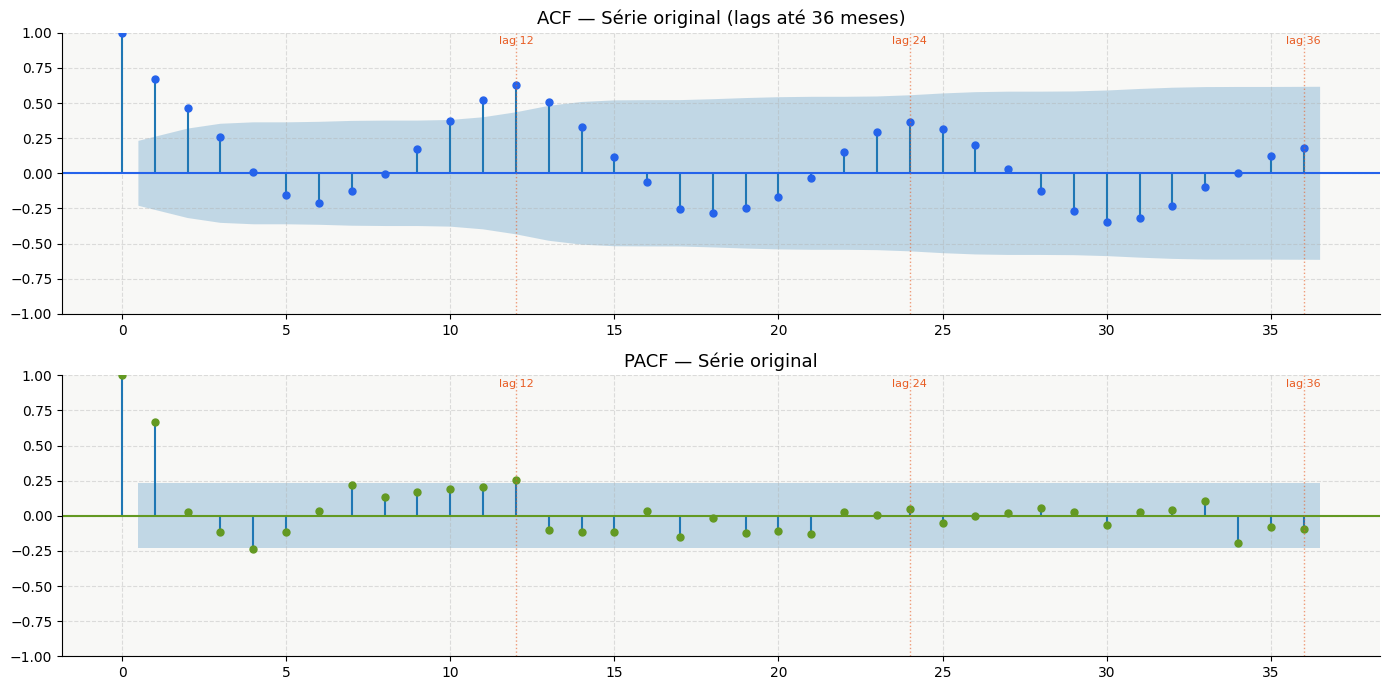

Observe os picos nos lags 12, 24, 36 → confirma sazonalidade anual (período = 12 meses)


In [164]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(serie, lags=36, ax=axes[0], color='#2563EB',
         title='ACF — Série original (lags até 36 meses)',
         alpha=0.05)  # banda de 95% de confiança

plot_pacf(serie, lags=36, ax=axes[1], color='#639922',
          title='PACF — Série original',
          method='ywm', alpha=0.05)

# Destacar lags múltiplos de 12
for ax in axes:
    for lag in [12, 24, 36]:
        ax.axvline(lag, color='#E85D24', linewidth=1, linestyle=':', alpha=0.6)
        ax.text(lag, ax.get_ylim()[1]*0.92, f'lag {lag}',
                ha='center', fontsize=8, color='#E85D24')

plt.tight_layout()
plt.show()

print('Observe os picos nos lags 12, 24, 36 → confirma sazonalidade anual (período = 12 meses)')

## 4. Separação treino e teste

Em séries temporais, **não podemos embaralhar os dados**.

O treino deve vir antes do teste, respeitando a ordem do tempo.

Usaremos os últimos 12 meses como teste.

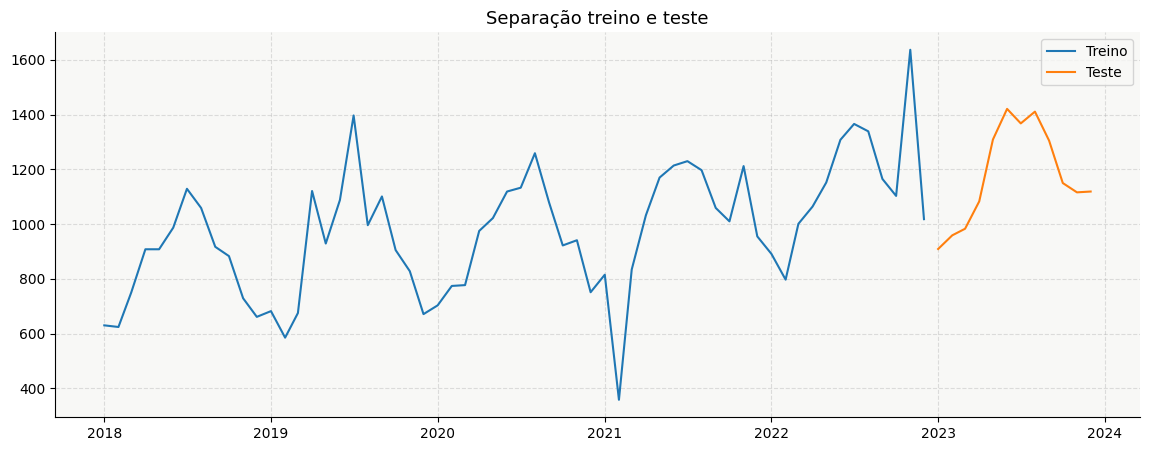

In [165]:
test_size = 12

train = serie.iloc[:-test_size]
test = serie.iloc[-test_size:]

plt.figure(figsize=(14,5))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label='Teste')
plt.title('Separação treino e teste')
plt.legend()
plt.show()

## 5. Função para avaliação dos modelos

Vamos comparar os modelos usando:

- MAE: erro absoluto médio;
- RMSE: raiz do erro quadrático médio;
- MAPE: erro percentual absoluto médio.

O MAPE é bastante usado em previsão de demanda porque expressa o erro em percentual.

In [166]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    return mae, rmse, mape

resultados = []

def registrar_resultado(nome_modelo, y_real, y_pred):
    mae, rmse, mape = calcular_metricas(y_real, y_pred)
    resultados.append({
        'modelo': nome_modelo,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    })

## 6. Modelo baseline: previsão ingênua

Antes de usar modelos sofisticados, devemos criar um baseline.

O modelo ingênuo assume que a próxima demanda será igual ao último valor observado.

Esse modelo é simples, mas serve como referência mínima.

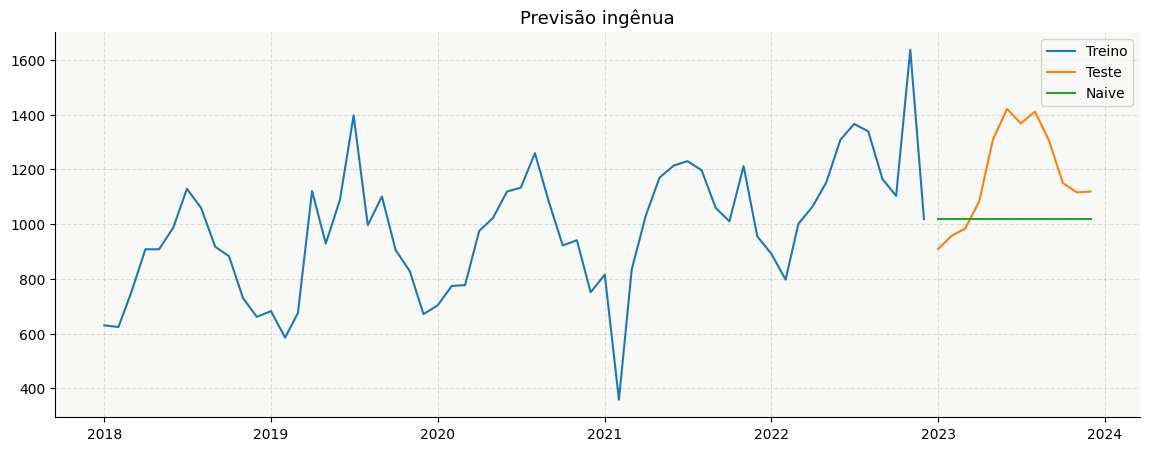

In [167]:
naive_pred = pd.Series(train.iloc[-1], index=test.index)

registrar_resultado('Naive', test, naive_pred)

plt.figure(figsize=(14,5))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label='Teste')
plt.plot(test.index, naive_pred, label='Naive')
plt.title('Previsão ingênua')
plt.legend()
plt.show()

## 7. Holt-Winters

O modelo Holt-Winters é uma extensão da suavização exponencial.

Ele pode considerar:

- nível;
- tendência;
- sazonalidade.

É um dos métodos clássicos mais úteis para previsão de demanda com padrão sazonal.

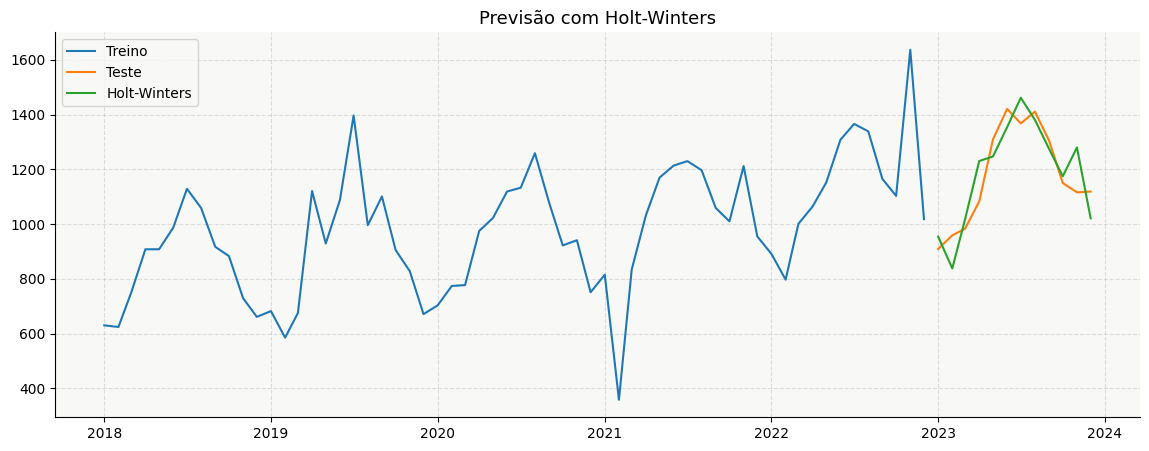

In [168]:
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

hw_pred = hw_model.forecast(test_size)
registrar_resultado('Holt-Winters', test, hw_pred)

plt.figure(figsize=(14,5))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label='Teste')
plt.plot(test.index, hw_pred, label='Holt-Winters')
plt.title('Previsão com Holt-Winters')
plt.legend()
plt.show()

## 8. ARIMA

O ARIMA combina três ideias:

- AR: usa valores passados da própria série;
- I: diferenciação para remover tendência;
- MA: usa erros passados do modelo.

A notação é:

\[
ARIMA(p,d,q)
\]

Onde:

- `p`: número de termos autoregressivos;
- `d`: número de diferenciações;
- `q`: número de termos de média móvel.

Neste exemplo usaremos uma especificação simples. Em uma aplicação real, poderíamos testar várias combinações.

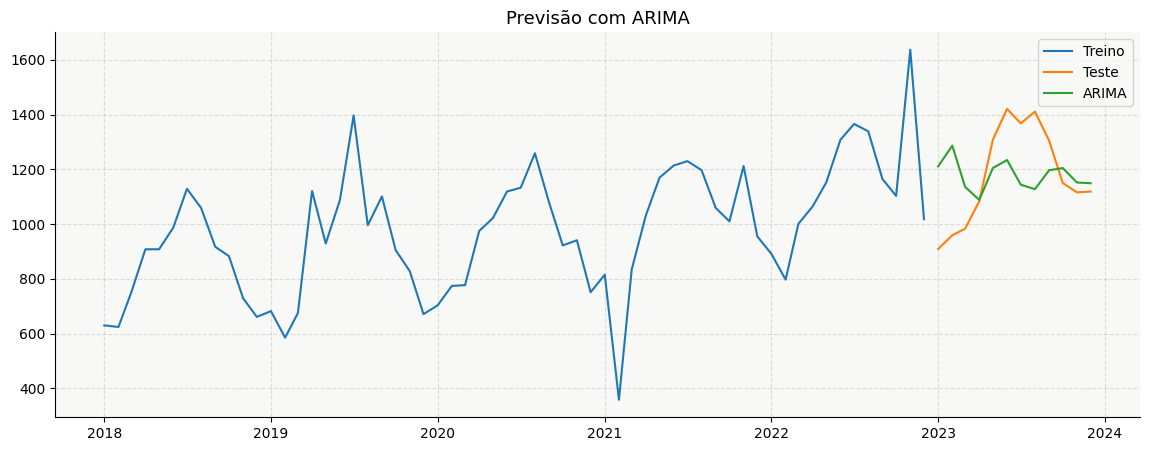

In [169]:
arima_model = ARIMA(train, order=(2, 1, 2)).fit()
arima_pred = arima_model.forecast(steps=test_size)

registrar_resultado('ARIMA(2,1,2)', test, arima_pred)

plt.figure(figsize=(14,5))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label='Teste')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.title('Previsão com ARIMA')
plt.legend()
plt.show()

## 9. SARIMA

O SARIMA é uma extensão do ARIMA para séries com sazonalidade.

A notação é:

\[
SARIMA(p,d,q)(P,D,Q,s)
\]

Onde:

- `p,d,q`: componentes não sazonais;
- `P,D,Q`: componentes sazonais;
- `s`: período sazonal.

Para dados mensais com sazonalidade anual, geralmente usamos `s = 12`.

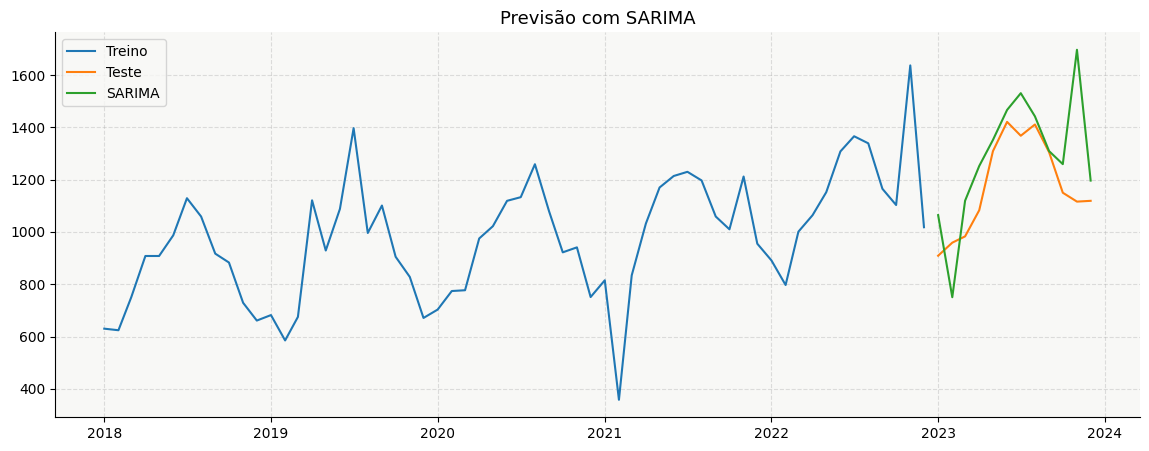

In [170]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_pred = sarima_model.forecast(steps=test_size)
registrar_resultado('SARIMA', test, sarima_pred)

plt.figure(figsize=(14,5))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label='Teste')
plt.plot(test.index, sarima_pred, label='SARIMA')
plt.title('Previsão com SARIMA')
plt.legend()
plt.show()

## 10. Machine Learning para previsão de demanda

Modelos de Machine Learning, como Random Forest e Gradient Boosting, não entendem automaticamente a ordem temporal.

Por isso, precisamos transformar a série temporal em uma tabela supervisionada.

Criamos variáveis como:

- lags: demanda dos períodos anteriores;
- médias móveis;
- mês;
- trimestre;
- ano.

In [171]:
def criar_features_temporais(df_original):
    dados = df_original.copy()

    dados['lag1'] = dados['demanda'].shift(1)
    dados['lag2'] = dados['demanda'].shift(2)
    dados['lag3'] = dados['demanda'].shift(3)
    dados['lag12'] = dados['demanda'].shift(12)

    dados['media_movel_3'] = dados['demanda'].rolling(3).mean()
    dados['media_movel_6'] = dados['demanda'].rolling(6).mean()
    dados['media_movel_12'] = dados['demanda'].rolling(12).mean()

    dados['mes'] = dados.index.month
    dados['trimestre'] = dados.index.quarter
    dados['ano'] = dados.index.year

    dados = dados.dropna()
    return dados

ml_df = criar_features_temporais(pd.DataFrame(serie))
ml_df.head()

,demanda,lag1,lag2,lag3,lag12,media_movel_3,media_movel_6,media_movel_12,mes,trimestre,ano
2019-01-01,682.0,661.0,729.0,883.0,630.0,690.666667,821.833333,853.083333,1,1,2019
2019-02-01,585.0,682.0,661.0,729.0,624.0,642.666667,742.833333,849.833333,2,1,2019
2019-03-01,675.0,585.0,682.0,661.0,750.0,647.333333,702.500000,843.583333,3,1,2019
2019-04-01,1121.0,675.0,585.0,682.0,908.0,793.666667,742.166667,861.333333,4,2,2019
2019-05-01,929.0,1121.0,675.0,585.0,908.0,908.333333,775.500000,863.083333,5,2,2019


## 11. Separação treino e teste para Machine Learning

A separação continua respeitando a ordem temporal.

A variável-alvo será `demanda_tratada`.

In [172]:
features = [
    'lag1', 'lag2', 'lag3', 'lag12',
    'media_movel_3', 'media_movel_6', 'media_movel_12',
    'mes', 'trimestre', 'ano'
]

target = 'demanda'

train_ml = ml_df.iloc[:-test_size]
test_ml = ml_df.iloc[-test_size:]

X_train = train_ml[features]
y_train = train_ml[target]

X_test = test_ml[features]
y_test = test_ml[target]

## 11. Random Forest Regressor

O Random Forest combina várias árvores de decisão.

Vantagens:

- robusto;
- fácil de usar;
- captura relações não lineares;
- exige pouco pré-processamento.

Limitação importante:

- árvores têm dificuldade para extrapolar tendências muito além do histórico observado.

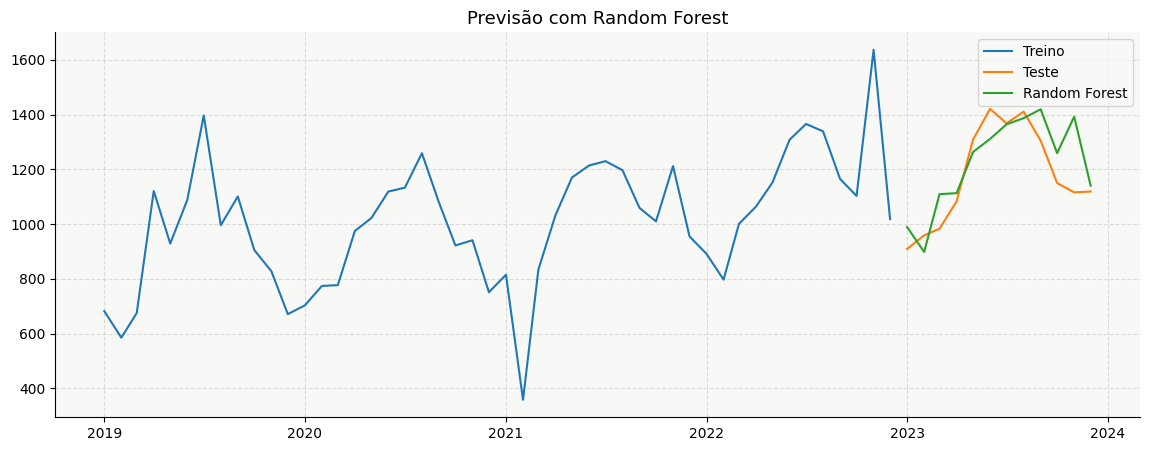

In [173]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = pd.Series(rf.predict(X_test), index=y_test.index)

registrar_resultado('Random Forest', y_test, rf_pred)

plt.figure(figsize=(14,5))
plt.plot(y_train.index, y_train, label='Treino')
plt.plot(y_test.index, y_test, label='Teste')
plt.plot(rf_pred.index, rf_pred, label='Random Forest')
plt.title('Previsão com Random Forest')
plt.legend()
plt.show()

## 12. Gradient Boosting Regressor

O Gradient Boosting também usa árvores, mas de forma sequencial.

Cada nova árvore tenta corrigir os erros das árvores anteriores.

É uma das ideias por trás de algoritmos populares como XGBoost, LightGBM e CatBoost.

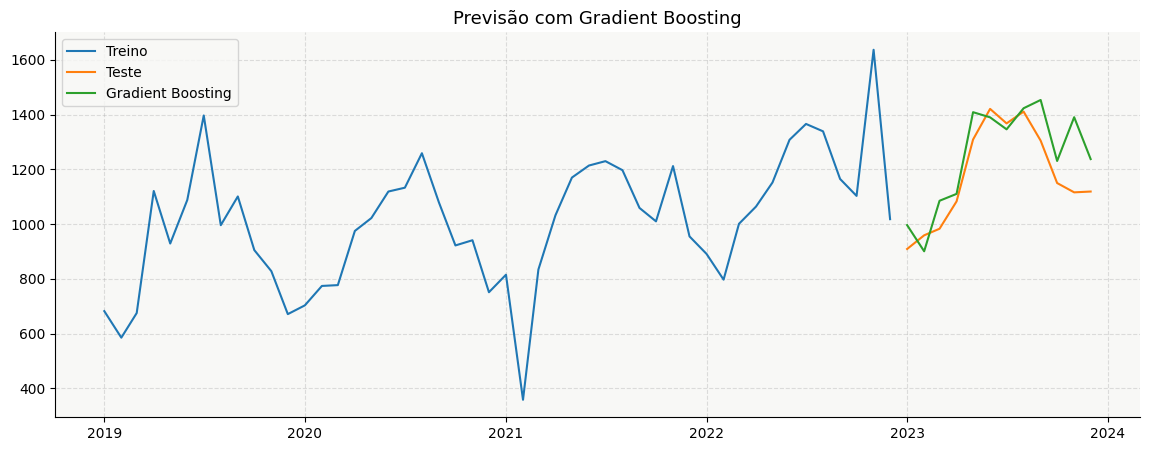

In [174]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = pd.Series(gb.predict(X_test), index=y_test.index)

registrar_resultado('Gradient Boosting', y_test, gb_pred)

plt.figure(figsize=(14,5))
plt.plot(y_train.index, y_train, label='Treino')
plt.plot(y_test.index, y_test, label='Teste')
plt.plot(gb_pred.index, gb_pred, label='Gradient Boosting')
plt.title('Previsão com Gradient Boosting')
plt.legend()
plt.show()

## 13. Importância das variáveis

Nos modelos baseados em árvores, podemos analisar a importância das variáveis.

Isso ajuda a responder perguntas como:

- A demanda do mês anterior é importante?
- A sazonalidade anual aparece no `lag12`?
- O mês do ano ajuda o modelo?

         variavel  importancia
3           lag12     0.704744
4   media_movel_3     0.182298
6  media_movel_12     0.034813
0            lag1     0.027769
1            lag2     0.016319
2            lag3     0.014514
5   media_movel_6     0.009542
7             mes     0.009147
9             ano     0.000705
8       trimestre     0.000149


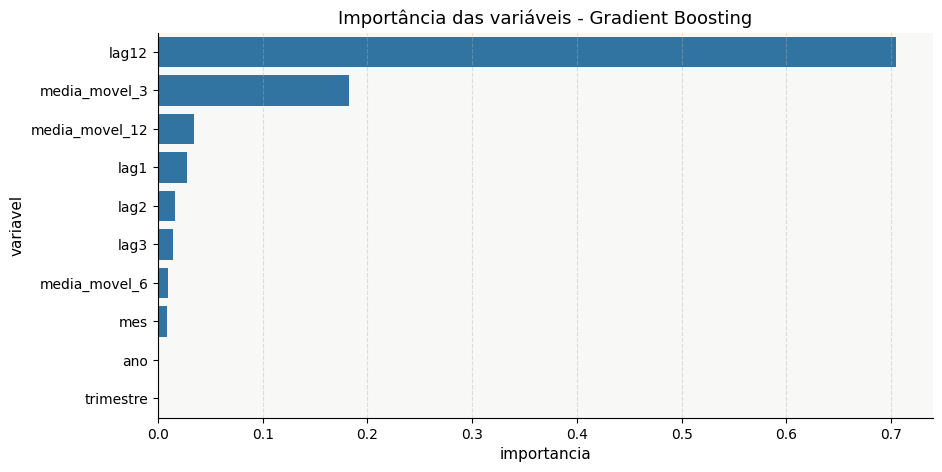

In [175]:
importancias = pd.DataFrame({
    'variavel': features,
    'importancia': gb.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias)

plt.figure(figsize=(10,5))
sns.barplot(data=importancias, x='importancia', y='variavel')
plt.title('Importância das variáveis - Gradient Boosting')
plt.show()

## 14. Comparação final dos modelos

Agora vamos comparar todos os modelos testados.

O melhor modelo não é necessariamente o mais sofisticado.

A escolha deve considerar:

- erro de previsão;
- facilidade de explicação;
- estabilidade;
- custo computacional;
- aderência ao problema de negócio.

In [176]:
resultado_final = pd.DataFrame(resultados).sort_values('MAPE (%)')
resultado_final

,modelo,MAE,RMSE,MAPE (%)
1,Holt-Winters,76.552631,89.310423,6.761201
4,Random Forest,83.493667,109.456462,7.410317
5,Gradient Boosting,88.550206,112.492863,7.874352
3,SARIMA,143.646470,204.447008,13.143893
2,"ARIMA(2,1,2)",151.302882,186.007351,13.333047
0,Naive,193.583333,235.309902,15.251008


## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  

## <h3 align="center"> (c) Liga Data Science/ UFPR 2026. All rights reserved. <h3/>

## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 18-05-2025       | 1.0     | Eduardo Pecora    | Inicial               ||

<hr>